\setcounter{secnumdepth}{0}

# Assignment 2.1 - Simulating dynamical systems in Jax

    Name: Sam Schilder
    Student #: s1154839

In [2]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.random import PRNGKey

# Exercise 1: Analytical solution of linear systems (3 points)
For linear systems $\dot{x} = A x$, we can often analytically compute the solution.

A) Using separation of variables, write down an analytical solution of the ordinary differential equation
$$\dfrac{dx}{dt} = \lambda x.$$
Make sure to express the solution with the initial condition.

B) Using this solution, plot the dynamics of the system over time given an initial condition and value of $\lambda$.

## Solution 1:


$$\frac{dx}{dt} = \lambda x$$

$$\frac{dx}{x} = \lambda \, dt$$

$$\int \frac{dx}{x} = \int \lambda \, dt$$

$$\ln|x| = \lambda t + c$$

$$x = e^{\lambda t} e^{c}$$

$$x = x_0 e^{\lambda t}$$
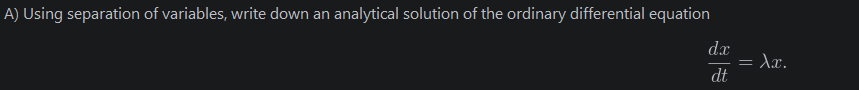

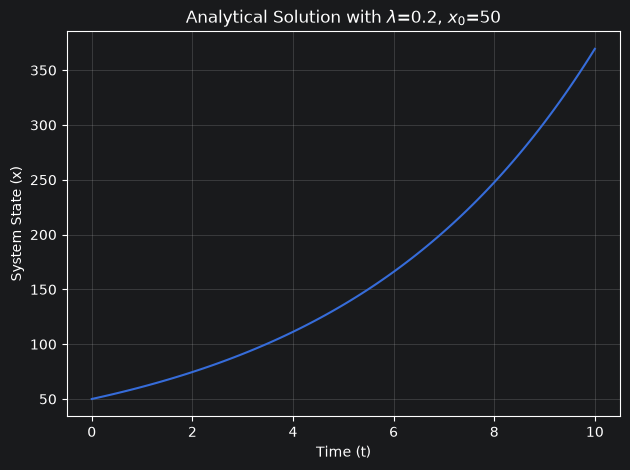

In [3]:
f = lambda x0, l, t: x0 * jnp.exp(l*t)  # analytical solution

x0 = 50  # initial condition
l = 0.2  # lambda

t = jnp.linspace(0, 10, 100)  # time
x  = f(x0, l, t)

# plot
plt.plot(t, x)
plt.xlabel('Time (t)')
plt.ylabel('System State (x)')
plt.title(rf'Analytical Solution with $\lambda$={l}, $x_0$={x0}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Exercise 2: Numerical approximation for the harmonic oscillator (7 points)

Not all systems can be solved analytically. For these systems, we can instead use numerical techniques to solve the integration in order to get the system's trajectory. You may implement the simulation using a for-loop or with jax.lax.scan() (which we advice).

### 2.1:

First we will visualize the analytical solution of the harmonic oscillator. The analytical solution of the harmonic oscillator is given by:

$$x(t) = cos(t)$$

$$v(t) = -sin(t)$$

Show the solution over the time range $t \in [0, 50]$

## 2.1 Solution:

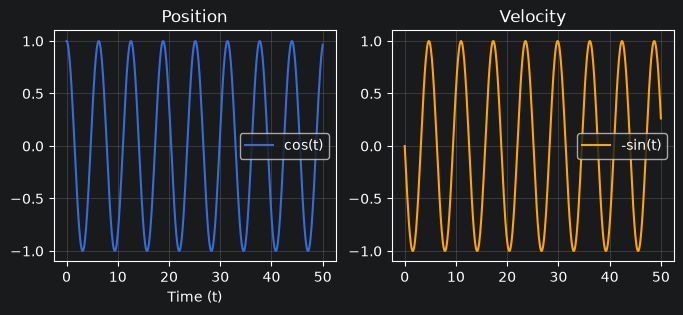

In [11]:
# functions
f1 = lambda t: jnp.cos(t)
f2 = lambda t: -jnp.sin(t)

t0 = 0  # starting time
tn = 50  # end time
num_points = 10*(tn-t0)

t = jnp.linspace(t0, tn, sf)  # time range
x  = f1(t); v = f2(t)

# plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(t, x, label='cos(t)')
axes[0].set_xlabel('Time (t)')
axes[0].set_title('Position')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, v, label='-sin(t)', color='orange')
axes[1].set_title('Velocity')
axes[0].set_xlabel('Time (t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

## 2.2:
Create a numerical approximation of the simple harmonic oscillator (i.e., the harmonic oscillator with a damping coefficient of zero) using the Euler method: $$  x_{n+1}=x_{n}+\Delta_t f(t_{n},x_{n}) $$

Solve the system forward in the range $t \in [0, 50]$ using varying step sizes, given some (non-zero) initial condition. Also show the analytical solution.

Comment on what you see, and explain your observations.

## Solution 2.2:

In [13]:
def simple_harmonic_oscillator(X, k):
    """
    Simple harmonic oscillator model
    X: state vector [x, xdot]
    k: omega
    """
    x, xdot = X
    return jnp.array([xdot, -k*x])

In [14]:
def euler(f, x, t, dt):
    """
    Euler approximation

    f: state equation function
    t: time at which the function is evaluated
    x: state vector at time k
    dt: step size

    Returns the state at time k+1
    """

    return x + dt * f(x, t)

In [15]:
# General Euler function
def get_euler(f, dt):
    def euler_scan_fn(carry, t):

        return carry + dt * f(carry, t), carry + dt * f(carry, t)

    return euler_scan_fn

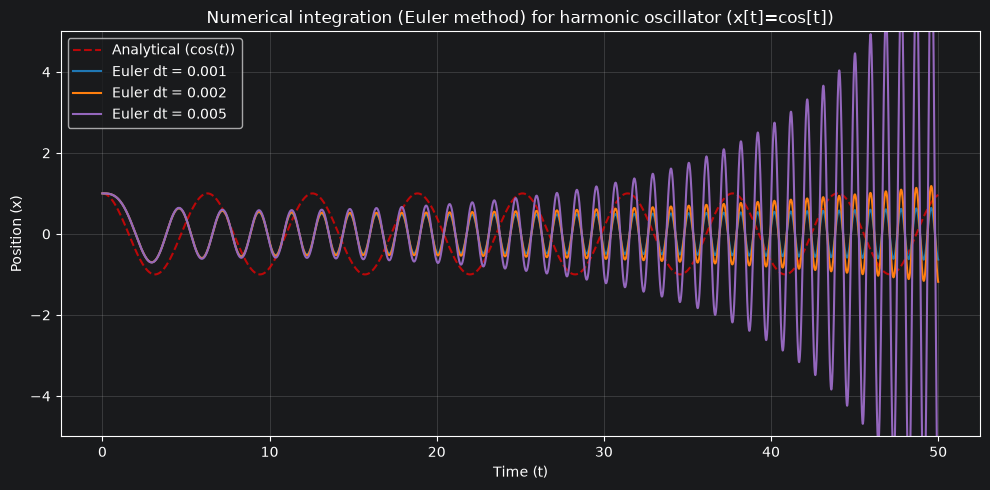

In [35]:
# Visualize the harmonic oscillator integrated with Euler for different step sizes
import time
color1 = 'r--'
color2_4 = ['tab:blue', 'tab:orange', 'tab:purple']
# parameters
t0 = 0  # starting time
tn = 50  # end time
dts = 0.001, 0.002, 0.005  # stepsize
t_analytical = jnp.linspace(t0, tn, 1000)
x0 = jnp.array([1.0, 0.0])

x  = f1(t); v = f2(t)
k = 1

# simulation
plt.figure(figsize=(10, 5))
plt.plot(t_analytical, jnp.cos(t_analytical), color1, label=r'Analytical ($\cos(t)$)', alpha=0.7)

for i, dt in enumerate(dts):  # loop over all stepsizes
    num_steps = int((tn-t0)/dt)
    t = jnp.linspace(t0, tn, num_steps)  # time range

    f = lambda X, k: simple_harmonic_oscillator(X, k)
    step_fn = get_euler(f, dt)
    _, trajectory = jax.lax.scan(step_fn, x0, t)

    # plot
    plt.plot(t, trajectory[:,0], color2_4[i], label=rf'Euler dt = {dt}')

plt.title('Numerical integration (Euler method) for harmonic oscillator (x[t]=cos[t])')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.ylim([-5, 5])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3

Write a RK4 solver and use it to simulate the simple harmonic oscillator. Using different step sizes, what do you observe? Compare your solution with Euler’s method. The RK4 solvers works as follows:

$$x_{n+1} = x_n + \frac{\Delta_t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$
$$t_{n+1} = t_n + \Delta_t$$
with
$$k_1 = f(t_n, x_n)$$
$$k_2 = f(t_n + \frac{\Delta_t}{2}, x_n + \Delta_t\frac{k_1}{2})$$
$$k_3 = f(t_n + \frac{\Delta_t}{2}, x_n + \Delta_t\frac{k_2}{2})$$
$$k_4 = f(t_n + \Delta_t, x_n + \Delta_t k_3)$$

## Solution 2.3

In [9]:
# General RK4 function
def get_rk4(f, dt):
    def rk4_scan_fn(carry, t):
        #YOUR ANSWER HERE
        return
    
    return rk4_scan_fn

In [10]:
#Visualize the harmonic oscillator integrated with RK4 for different step sizes